In [1]:
import pandas as pd
import sys
sys.path.append('..')
from src.data.data import download_event_file

In [2]:
list_of_subs = [
                'sub-P10',
                'sub-P12',
                'sub-P13',
                'sub-P14',
                'sub-P15',
                'sub-P16',
                'sub-P17',
                'sub-P18',
                'sub-P19',
            #    'sub-P20', Unattentive
                'sub-P21',
                'sub-P22',
                'sub-P23',
                'sub-P25',
        #        'sub-P26', missing event file
                'sub-P27',
        #        'sub-P30', incomplete data
                'sub-P31',
                'sub-P34',
                'sub-P35',
                'sub-P36',
                'sub-P37',
                'sub-P41',
                'sub-P42',
                'sub-P43',
                'sub-P44',
                'sub-P45',
                'sub-P47',
                'sub-P48',
        #        'sub-P49',   Unattentive
                'sub-P50',
                'sub-P51',
                ]

In [3]:
pre_events_df = pd.DataFrame()
for sub in list_of_subs:
    sub_events = pd.read_csv(download_event_file(sub,'ses-01'), sep='\t')
    sub_events['subject'] = sub
    pre_events_df = pd.concat([pre_events_df, sub_events[['onset', 'duration', 'event', 'subject']]]).copy()
pre_events_df.head()

[download_event_file] Executing command: scp boesch@miplabsrv3:/media/RCPNAS/Data3/Alison_island/bids_ackbar/sub-P10/ses-01/func/sub-P10_ses-01_task-viewing_run-01_events.tsv data/preprocessed/sub-P10/func/
[download_event_file] Downloaded event file for sub-P10, ses-01 to data/preprocessed/sub-P10/func.
[download_event_file] Executing command: scp boesch@miplabsrv3:/media/RCPNAS/Data3/Alison_island/bids_ackbar/sub-P12/ses-01/func/sub-P12_ses-01_task-viewing_run-01_events.tsv data/preprocessed/sub-P12/func/
[download_event_file] Downloaded event file for sub-P12, ses-01 to data/preprocessed/sub-P12/func.
[download_event_file] Executing command: scp boesch@miplabsrv3:/media/RCPNAS/Data3/Alison_island/bids_ackbar/sub-P13/ses-01/func/sub-P13_ses-01_task-viewing_run-01_events.tsv data/preprocessed/sub-P13/func/
[download_event_file] Downloaded event file for sub-P13, ses-01 to data/preprocessed/sub-P13/func.
[download_event_file] Executing command: scp boesch@miplabsrv3:/media/RCPNAS/Data3

,onset,duration,event,subject
0,4.634,3.017,maya_3_e3_6_r_h_v1_old.jpg,sub-P10
1,11.701,3.017,wealth_5_e3_7_nr_o_v1_old.jpg,sub-P10
2,17.934,3.017,pirate_6_e2_13_r_h_v1_old.jpg,sub-P10
3,24.534,3.017,viking_11_new.jpg,sub-P10
4,30.451,3.016,pirate_7_e3_1_nr_h_v1_old.jpg,sub-P10


In [4]:
one_hot = ['old', 'maya', 'wealth', 'pirate', 'food', 'drink', 'viking','_h_', '_r_', 'e1', 'e2', 'e3']
for col in one_hot:
    pre_events_df[col] = pre_events_df['event'].str.contains(col, case=False, na=False)
    # keep only 64th first rows for each subject to avoid including practice trials
    #pre_events_df = pre_events_df.head(64).copy()
pre_events_df.head()

,onset,duration,event,subject,old,maya,wealth,pirate,food,drink,viking,_h_,_r_,e1,e2,e3
0,4.634,3.017,maya_3_e3_6_r_h_v1_old.jpg,sub-P10,True,True,False,False,False,False,False,True,True,False,False,True
1,11.701,3.017,wealth_5_e3_7_nr_o_v1_old.jpg,sub-P10,True,False,True,False,False,False,False,False,False,False,False,True
2,17.934,3.017,pirate_6_e2_13_r_h_v1_old.jpg,sub-P10,True,False,False,True,False,False,False,True,True,False,True,False
3,24.534,3.017,viking_11_new.jpg,sub-P10,False,False,False,False,False,False,True,False,False,False,False,False
4,30.451,3.016,pirate_7_e3_1_nr_h_v1_old.jpg,sub-P10,True,False,False,True,False,False,False,True,False,False,False,True


In [5]:
from src.core.contrast_types import HUMAN_CATEGORIES
pre_events_df['human'] = pre_events_df[HUMAN_CATEGORIES].any(axis=1)

# Analysis

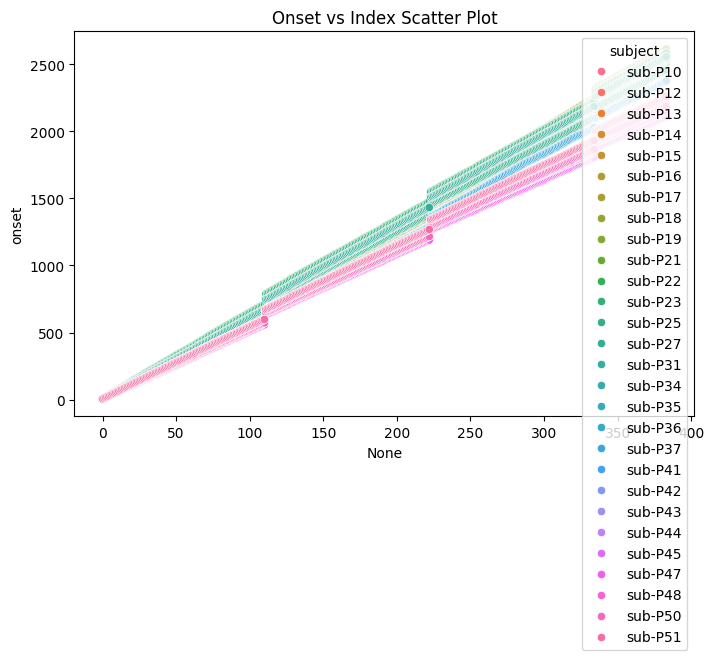

[223, 335, 111]

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, chi2_contingency
# scatter plot onset vs idx
plt.figure(figsize=(8, 5))
sns.scatterplot(x=pre_events_df.index, y='onset', hue='subject', data=pre_events_df)
plt.title('Onset vs Index Scatter Plot')
plt.show()  
# get idx of values where the next onset is at more than 20s distance
large_gaps_idx = pre_events_df.index[pre_events_df['onset'].diff().fillna(0) > 20].tolist()
# get unique values
large_gaps_idx = list(set(large_gaps_idx))
large_gaps_idx

In [7]:
# print old value for +-1 of each large gap
for sub in list_of_subs:
    sub_events = pre_events_df[pre_events_df['subject'] == sub].copy()
    for idx in large_gaps_idx:
        print(sub_events.loc[idx-1:idx+1, ['old']])

      old
222  True
223  True
224  True
      old
334  True
335  True
336  True
       old
110  False
111   True
112   True
       old
222  False
223   True
224   True
       old
334  False
335   True
336   True
       old
110  False
111   True
112   True
       old
222  False
223  False
224  False
      old
334  True
335  True
336  True
      old
110  True
111  True
112  True
       old
222   True
223  False
224  False
      old
334  True
335  True
336  True
       old
110  False
111   True
112   True
       old
222  False
223   True
224  False
      old
334  True
335  True
336  True
       old
110   True
111   True
112  False
       old
222  False
223  False
224   True
       old
334   True
335  False
336   True
       old
110  False
111   True
112   True
       old
222   True
223   True
224  False
       old
334   True
335   True
336  False
       old
110  False
111   True
112   True
      old
222  True
223  True
224  True
      old
334  True
335  True
336  True
       old
110  Fals

In [8]:

def analysis(_x = 'old', y='onset'):
    # Detect if y is categorical (0/1 or boolean)
    is_categorical = set(pre_events_df[y].dropna().unique()).issubset({0, 1, True, False})
    
    if is_categorical:
        # ---- CATEGORICAL CASE ----
        # Contingency table
        contingency = pd.crosstab(pre_events_df[_x], pre_events_df[y])
        chi2, p, dof, expected = chi2_contingency(contingency)
        
        # Plot counts
        sns.countplot(x=_x, hue=y, data=pre_events_df)
        plt.title(f'Count of {y} = 1 vs 0 for {_x.capitalize()} Stimuli')
        plt.show()
        
        print("Categorical variable detected.")
        print(f"Chi-square test: χ² = {chi2:.3f}, p-value = {p:.4g}")
    
    else:
        # ---- CONTINUOUS CASE ----
        sns.barplot(x=_x, y=y, data=pre_events_df, errorbar='sd')
        plt.title(f'{y.capitalize()} values for {_x.capitalize()} Stimuli')
        plt.show()
        
        # Independent samples t-test
        old_vals = pre_events_df[pre_events_df[_x] == True][y].dropna()
        new_vals = pre_events_df[pre_events_df[_x] == False][y].dropna()
        
        t_stat, p_value = ttest_ind(old_vals, new_vals, equal_var=False)
        print("Continuous variable detected.")
        print(f"T-test between {_x.capitalize()} stimuli {y}: t = {t_stat:.3f}, p = {p_value:.4g}")


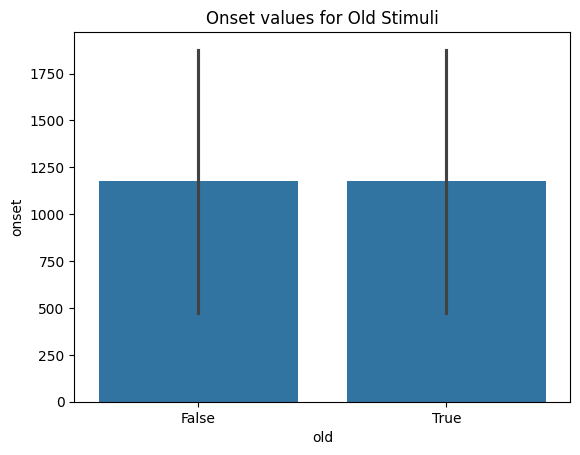

Continuous variable detected.
T-test between Old stimuli onset: t = 0.028, p = 0.9778


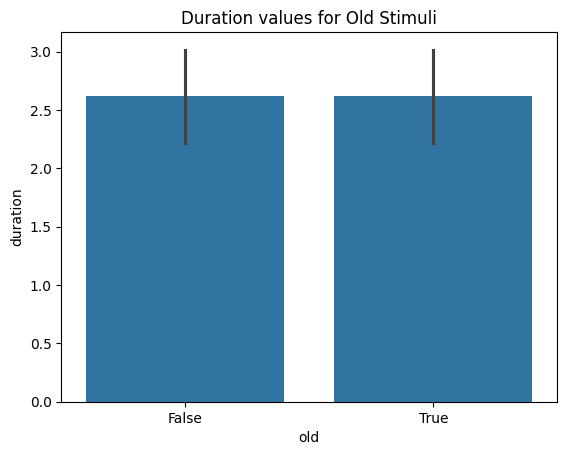

Continuous variable detected.
T-test between Old stimuli duration: t = -0.003, p = 0.9974


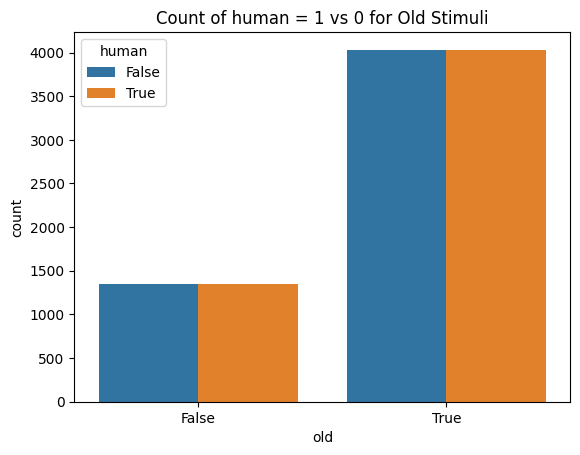

Categorical variable detected.
Chi-square test: χ² = 0.000, p-value = 1


In [9]:
analysis(y='onset')
analysis(y='duration')
analysis(y='human')

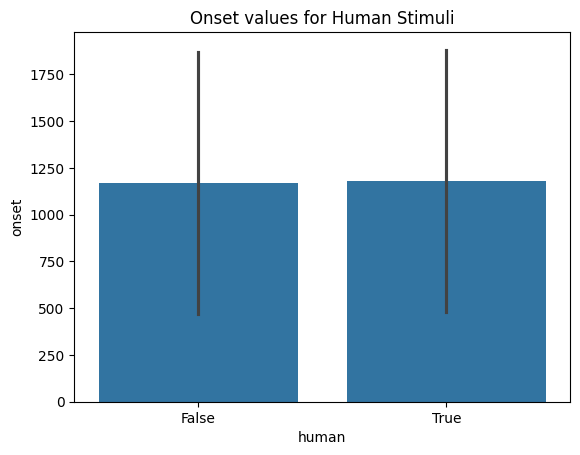

Continuous variable detected.
T-test between Human stimuli onset: t = 0.720, p = 0.4715


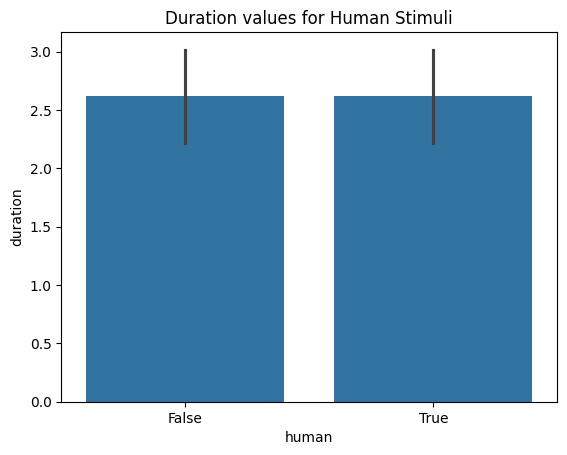

Continuous variable detected.
T-test between Human stimuli duration: t = 0.003, p = 0.998


In [10]:
analysis('human', 'onset')
analysis('human', 'duration')

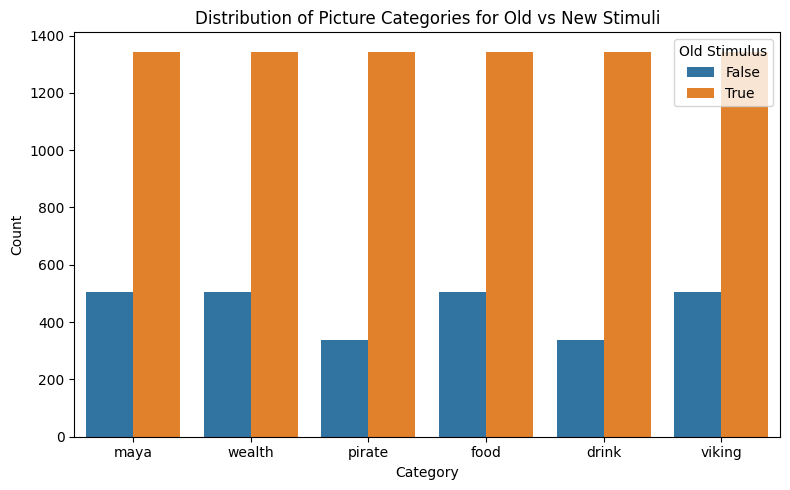

In [11]:
# Select only the categorical/object columns
object_cols = ['maya', 'wealth', 'pirate', 'food', 'drink', 'viking']

# Melt the dataframe to long format for easier plotting
melted_df = pre_events_df.melt(
    id_vars=['old'], 
    value_vars=object_cols, 
    var_name='category', 
    value_name='is_present'
)

# Keep only rows where the category is True (image belongs to that category)
melted_df = melted_df[melted_df['is_present'] == True]

# Plot the counts
plt.figure(figsize=(8, 5))
sns.countplot(x='category', hue='old', data=melted_df)
plt.title('Distribution of Picture Categories for Old vs New Stimuli')
plt.xlabel('Category')
plt.ylabel('Count')
plt.legend(title='Old Stimulus')
plt.tight_layout()
plt.show()

In [ ]:
from src.core.contrast_types import controlled_randomization_of_trials
sub_10_events = pre_events_df[pre_events_df['subject'] == 'sub-P10'].copy()
sub_10_events.rename(columns={'event': 'trial_type'}, inplace=True)
events = controlled_randomization_of_trials(sub_10_events)
events.head()

Index(['onset', 'duration', 'trial_type', 'subject', 'old', 'maya', 'wealth',
       'pirate', 'food', 'drink', 'viking', '_h_', '_r_', 'e1', 'e2', 'e3',
       'human'],
      dtype='object')
group
random1    192
random2    192
Name: count, dtype: int64
old_new                    old
group   category r_nr o_h     
random1 drink    nr   o     12
                 r    o     13
        food     nr   o     16
                 r    o     12
        maya     nr   h      9
                 r    h     13
        pirate   nr   h     10
                 r    h     13
        viking   nr   h     14
                 r    h     13
        wealth   nr   o      9
                 r    o     14
random2 drink    nr   o     12
                 r    o     11
        food     nr   o      8
                 r    o     12
        maya     nr   h     15
                 r    h     11
        pirate   nr   h     14
                 r    h     11
        viking   nr   h     10
                 r    h     11
 

,onset,duration,trial_type,subject,old,maya,wealth,pirate,food,drink,...,e3,human,category,r_nr,o_h,old_new,onset_bin,duration_bin,stratum,group
0,1812.324,3.017,maya_2_e1_1_nr_h_v1_old.jpg,sub-P10,True,True,False,False,False,False,...,False,True,maya,nr,h,old,"(1254.658, 1931.685]","(3.0169999999998, 3.0170000000001]","maya_nr_h_old_(1254.658, 1931.685]_(3.01699999...",random1
1,1695.159,3.017,pirate_10_new.jpg,sub-P10,False,False,False,True,False,False,...,False,True,pirate,NaN,NaN,new,"(1254.658, 1931.685]","(3.0169999999998, 3.0170000000001]","pirate_nan_nan_new_(1254.658, 1931.685]_(3.016...",random1
2,2430.565,3.017,wealth_11_new.jpg,sub-P10,False,False,True,False,False,False,...,False,False,wealth,NaN,NaN,new,"(1931.685, 2606.362]","(3.0160000000001, 3.0169999999998]","wealth_nan_nan_new_(1931.685, 2606.362]_(3.016...",random1
3,2216.685,3.016,maya_2_e1_1_nr_h_v1_old.jpg,sub-P10,True,True,False,False,False,False,...,False,True,maya,nr,h,old,"(1931.685, 2606.362]","(3.0159999999995, 3.0160000000001]","maya_nr_h_old_(1931.685, 2606.362]_(3.01599999...",random1
4,344.946,3.017,maya_11_new.jpg,sub-P10,False,True,False,False,False,False,...,False,True,maya,NaN,NaN,new,"(4.633, 589.384]","(3.0169999999998, 3.0170000000001]","maya_nan_nan_new_(4.633, 589.384]_(3.016999999...",random1


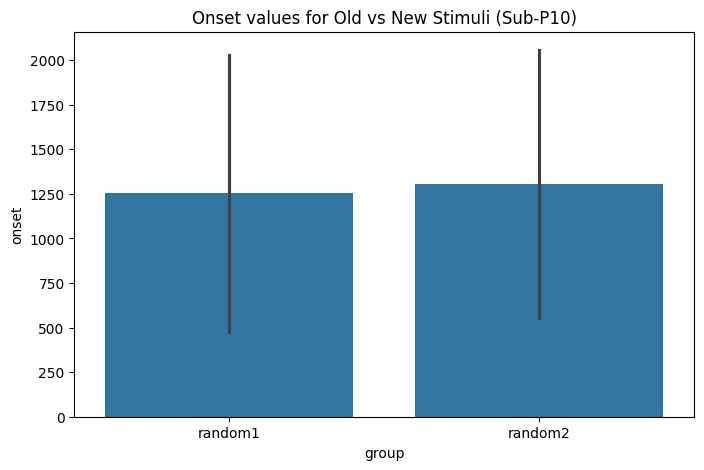

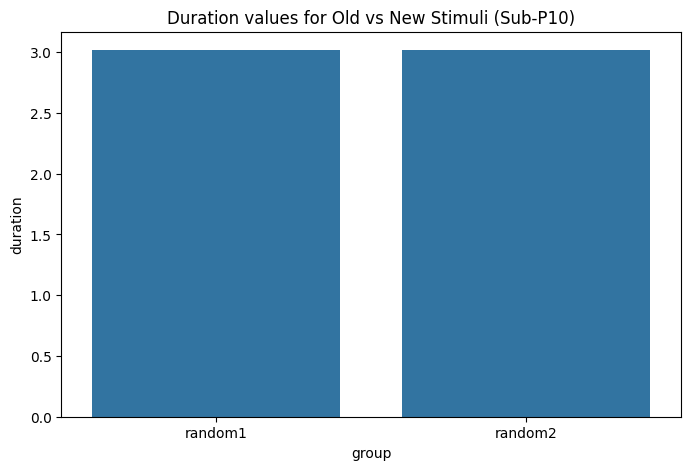

In [16]:
# plot duration and onset of the two groups
for y in ['onset', 'duration']:
    plt.figure(figsize=(8, 5))
    sns.barplot(x='group', y=y, data=events, errorbar='sd')
    plt.title(f'{y.capitalize()} values for Old vs New Stimuli (Sub-P10)')